# Gaussian process for enzyme discovery with `evedesign`

This notebook is a companion to [`supervised_enzyme_discovery.ipynb`](./supervised_enzyme_discovery.ipynb), where a Random Forest model w/ ESM-2 embeddings was trained to predict KYNase catalytic efficiency ($k_{cat}/K_m$).

Here we do two things differently:

1. **Model:** We swap the Random Forest for a **Gaussian process** (`evedesign.models.supervised.GpytorchModel`). GP gives a **calibrated posterior predictive uncertainty** for each prediction.
2. **Features:** Sequences are embedded using the `OneHotEmbedder`

In [ ]:
import torch
import pandas as pd
import numpy as np

from evedesign.system import System, Protein, SystemInstance, EntityInstance
from evedesign.models.embedders import OneHotEmbedder
from evedesign.models import supervised
from evedesign import dataset
from evedesign.sequence import read_fasta

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## 1. Obtain training data

We reuse the same training set as the Random Forest notebook (`training_data.csv`), originally from [Eom *et al.*]. Each row is a KYNase homolog with its measured catalytic efficiency $k_{cat}/K_m$.

In [2]:
training_df = pd.read_csv("training_data.csv")
training_df.head()

,name,kcat/km,seq
0,Pf-KYNU|Pf-KYNU|76000,76000.0,MTSRSHCQTLDAQDPLAPLRDQFALPAGVIYLDGNSLGARPVASLA...
1,Mp-KYNU|Mp-KYNU|57000,57000.0,MNYQNTLAFARELDEQDNLAGFRNEFIIPQHHGRDMIYLCGNSLGL...
2,Ab-KYNU|Ab-KYNU|54000,54000.0,MITREQCLYWDQEDELKKFKDEFALPEGVIYLDGNSLGARPKKSLA...
3,Mm-KYNU|Mm-KYNU|520,520.0,MEPSPLELPVDAVRRIAAELNCDPTDERVALRLDEEDKLSHFRNCF...
4,Cp-KYNU|Cp-KYNU|27000,27000.0,MIEKLKQYHDEAISLDSLDPLQKFKECFTLPKEPGALYFCSNSLGL...


The reference sequence used in the original study is the KYNase from *Pseudomonas fluorescens* (Pf-K), which is the first entry of the training set.

In [3]:
pfk_seq = training_df.iloc[0]["seq"]
pfk_seq

'MTSRSHCQTLDAQDPLAPLRDQFALPAGVIYLDGNSLGARPVASLARAQQVIAEEWGNGLIRSWNSAGWADLSLRLGNRLAPLIGAGAGEVAITDTTSINLFKVLSAALTVQRQREPARKVIVSEASNFPTDLYIAEGLAELLQQGYCLRLVNSPDELPQAIDADVAVVMLTHVNYKTGYMYDMQALTALSHECGALSIWDLAHSAGAVPIDLRAAGADYAIGCTYKYLNGGPGSQAFVWVNPALVDQVRQPLSGWFGHTRQFAMESNYAPSAGIARYLCGTQPITSLAMVECGLQIFEQTDMACLRRKSLALTDLFIALVEARCAAHGLVLITPREHARRGSHVSFEHPEGYAVIQALIARGVIGDYREPRIMRFGFTPLYTRFSEVWDAVEILGEILDESTWDQPQFKVRHSVT'

## 2. Define system and build the one-hot embedder

We use the reference Pf-K sequence as the entity representative; the embedder only needs the system to determine the alphabet (20 amino acids + gap), and each instance is encoded from its own sequence regardless of length.

`OneHotEmbedder` produces a per-residue matrix of shape `[length, 21]`. The homologs have different lengths (416–466 residues), so we let the supervised model mean-pool across positions (`pooling="mean"`).

In [15]:
system = System(
    Protein(
        id="Pf-K", rep=pfk_seq, first_index=1, sequences=None, structures=None
    )
)

embedder = OneHotEmbedder().build(system)

## 3. Train the Gaussian process with cross-validation

One `SystemInstance` per sequence, labelled with `kcat/km`, and a 5-fold cross-validation split (`splits=("cv", 5)`) so `build()` reports held-out performance.

In [5]:
instances = [
    SystemInstance(EntityInstance(rep=seq))
    for seq in training_df["seq"]
]

dataset = dataset.LabeledInstanceDataset(
    instances=instances,
    labels={
        "kcat/km": training_df["kcat/km"].tolist()
    },
    splits=("cv", 5)  # noqa
)

`GpytorchModel` is configured with `use_embeddings=True` and `use_scores=False`: the `OneHotEmbedder` has no scoring capability, so (unlike ESM) there is no model score to use as a feature.

For the GP components we use the class defaults:

- **Mean:** `ConstantMean`
- **Covariance:** `ScaleKernel(RBFKernel())` — an RBF (squared-exponential) kernel with a learned output scale
- **Likelihood:** `GaussianLikelihood` (homoscedastic observation noise)
- **Objective:** `ExactMarginalLogLikelihood`, maximised with `Adam`

`standardize_targets=True` centres and scales the raw `kcat/km` targets for numerical stability during fitting and inverts the transform on prediction, so predictions come back on the original $k_{cat}/K_m$ scale. Passing ex. `covar_module=gpytorch.kernels.ScaleKernel(gpytorch.kernels.MaternKernel())` would swap in a different kernel.

In [16]:
p = supervised.GpytorchModel(
    embedder=embedder,
    use_embeddings=True,
    use_scores=False,
    pooling="mean",
    # GP components default ConstantMean + ScaleKernel(RBFKernel) + GaussianLikelihood
    num_iters=150,
    learning_rate=0.1,
    standardize_targets=True,
    device=DEVICE,
).build(system, data=dataset)

We can now check cross-validation performance. `stats()` returns the concatenated held-out predictions (`y_pred`) and truths (`y_true`) across folds, plus the per-fold regression metrics (Spearman, Pearson, R²).

In [7]:
model_stats = p.stats()

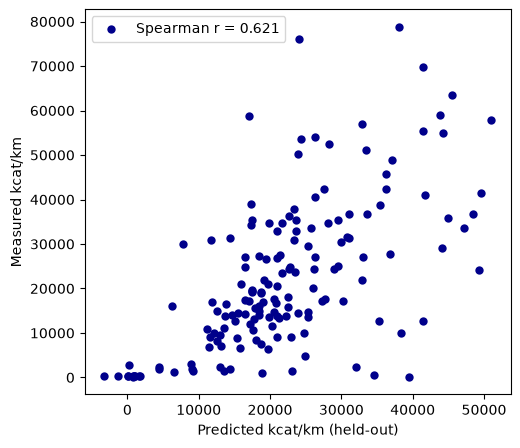

In [23]:
try:
    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns

    mean_spearman = np.array(model_stats["scores"]["spearman"]).mean()

    plt.figure(figsize=(5.5, 5))

    ax = sns.scatterplot(
        x=np.concatenate(model_stats["y_pred"]),
        y=np.concatenate(model_stats["y_true"]),
        linewidth=0,
        color="darkblue",
        label=f"Spearman r = {mean_spearman:.3f}",
    )

    ax.set_xlabel("Predicted kcat/km (held-out)")
    ax.set_ylabel("Measured kcat/km")

    plt.legend(loc="upper left")

    plt.show()
except ImportError:
    print("Install seaborn for this visualization")

Swapping OHE for a richer embedder (e.g. `ESM2` or `BLOSUMEmbedder`) is a one-line change if you want to push performance further.

## 4. Predict homolog catalytic efficiency with uncertainty

The main advantage of the GP over the Random Forest here is that every prediction comes with a **posterior predictive standard deviation**. `GpytorchModel.score()` attaches the posterior mean to `instance.score` *and* the posterior standard deviation to `instance.confidence`, both on the original $k_{cat}/K_m$ scale. This tells us not just *which* homologs are predicted to be efficient, but *how confident* the model is (useful for prioritizing which candidates to test experimentally).

We score a handful of homologs from the `nonredundant_target_sequences.fasta` file used in the original study.

In [10]:
NUM_SEQS = 20
CANONICAL_AA = set("ACDEFGHIKLMNPQRSTVWY")

In [24]:
with open("nonredundant_target_sequences.fasta") as f:
    seqs = [seq for (header, seq) in read_fasta(f)]

seqs_filtered = [
    seq for seq in seqs
    if set(seq) <= CANONICAL_AA and len(seq) <= 500
][:NUM_SEQS]

homolog_instances = [
    SystemInstance(EntityInstance(rep=seq))
    for seq in seqs_filtered
]

len(homolog_instances)

20

In [12]:
homolog_instances_scored = p.score(homolog_instances)

We collect the predicted mean and its uncertainty into a dataframe and rank the homologs by predicted catalytic efficiency. The `confidence` column is the posterior standard deviation (in $k_{cat}/K_m$ units)

In [13]:
df_homologs = pd.DataFrame({
    "sequence": seqs_filtered,
    "predicted_kcat_km": [inst.score for inst in homolog_instances_scored],
    "posterior_std": [inst.confidence for inst in homolog_instances_scored],
    "length": [len(seq) for seq in seqs_filtered],
})

df_homologs = df_homologs.sort_values("predicted_kcat_km", ascending=False).reset_index(drop=True)
df_homologs

,sequence,predicted_kcat_km,posterior_std,length
0,MTTRNDCLTLDAQDALAPLRQQFALPEGVIYLDGNSLGARPVAALA...,54812.280846,21541.789814,416
1,MISRNHCQTLDAQDPLAPLRYQFALPEGVIYLDGNSLGARPVAALA...,54061.616082,21783.633307,416
2,MTTRNACLALDAEDSLAPLRQQFALPQGVIYLDGNSLGARPVAALA...,53308.146827,22003.483791,416
3,MITRNDCLALDAQDPLAHLRHQFALPEGVIYLDGNSLGARPIAALE...,50457.616118,22750.707236,416
4,MTTRNDCLALDAQDALAALRDQFALPEGVIYLDGNSLGARPVAALE...,50447.635068,22750.711318,416
5,MTTRNDCLARDAQDTLAPLRQQFALPEGVIYLDGNSLGARPVAALA...,46378.771276,23551.487484,416
6,MTTRNHCLALDAQDPLAPLRDQFALPEGVIYLDGNSLGARPVASLQ...,46258.361849,23574.027512,416
7,MIDKNHCLRLDEQDPLAPLRQQFALPEGVIYLDGNSLGARPVASLE...,45313.921839,23714.952180,416
8,MTTRNDCLALDAQDTLAPLRDQFALPEGVIYLDGNSLGARPKASLE...,45065.612095,23750.220598,416
9,MIDKNHCLILDEQDPLAHLRQQFTLPDGVIYLDGNSLGARPRNAGE...,42457.688256,24055.134529,416


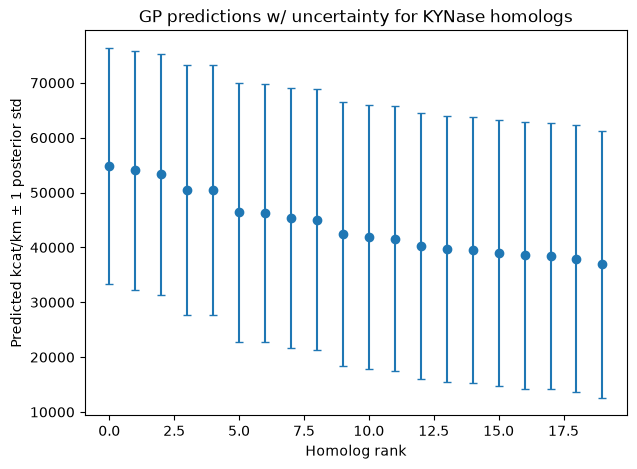

In [26]:
# visualise ranked predictions with +/- 1 posterior stdev
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(7, 5))
    rank = np.arange(len(df_homologs))
    ax.errorbar(
        rank,
        df_homologs["predicted_kcat_km"],
        yerr=df_homologs["posterior_std"],
        fmt="o",
        capsize=3,
    )
    ax.set_xlabel("Homolog rank")
    ax.set_ylabel("Predicted kcat/km ± 1 posterior std")
    ax.set_title("GP predictions w/ uncertainty for KYNase homologs")
    plt.show()
except ImportError:
    print("Install matplotlib for this visualization")

## References

Eom H, Park S, Cho KS, et al. Discovery of highly active kynureninases for cancer immunotherapy through protein language model. Nucleic Acids Res. 2025;53(1):gkae1245. https://doi.org/10.1093/nar/gkae1245

Gardner JR, Pleiss G, Bindel D, Weinberger KQ, Wilson AG. GPyTorch: Blackbox Matrix-Matrix Gaussian Process Inference with GPU Acceleration. NeurIPS 2018. https://doi.org/10.48550/arXiv.1809.11165